In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import os
from dotenv import load_dotenv
load_dotenv()
import tidy3d as td
from tidy3d import web
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import sys
import pandas as pd

# Assuming /AutomationModule is in the root directory of your project
sys.path.append(os.path.abspath(r'H:\codes\tidy3d'))

from AutomationModule import * 

import AutomationModule as AM

In [2]:
tidy3dAPI = os.environ["API_TIDY3D_KEY"]

In [3]:
a = 1
medium = td.Medium(permittivity=11.56)
run = True

In [4]:
lambdas =  1/np.array([0.15,0.85])

In [5]:
folder_path=rf"./Structures"
polarization = "TM"
add_field_monitor = True
project_name = fr"20260526 Transmission gyromorphs - SHU 100 x 15 Aaron {polarization}{" Field" if add_field_monitor else ""}"
empty=False
runtime_ps = 20e-12
min_steps_per_lambda = 15
id0 = ""
add_ref = True
Lx, Ly = 100, 15


In [6]:
def get_scale_factor(data,N):
    xmin, xmax = data['x'].min(), data['x'].max()
    ymin, ymax = data['y'].min(), data['y'].max()
    Lx = xmax - xmin
    Ly = ymax - ymin
    A = Lx * Ly
    density = N / A
    scale = np.sqrt(density)
    print(f'  N = {N}')
    print(f'  x range: [{xmin:.6f}, {xmax:.6f}]  Lx = {Lx:.6f}')
    print(f'  y range: [{ymin:.6f}, {ymax:.6f}]  Ly = {Ly:.6f}')
    print(f'  Area A = {A:.6f}')
    print(f'  Density N/A = {density:.6f}')
    print(f'  Scale factor to get N/A = 1: multiply coords by sqrt(N/A) = {scale:.6f}')
    print(f'  (resulting box size: Lx*scale = {Lx*scale:.6f}, Ly*scale = {Ly*scale:.6f})')
    return {"scale": scale, "Lx": Lx, "Ly": Ly, "xmin": xmin, "xmax": xmax, "ymin": ymin, "ymax": ymax}

In [7]:
data = []
scales_data = []
for l,file in enumerate((os.listdir(folder_path))):
    print(Path(file).stem)
    df = pd.read_csv(os.path.join(folder_path, file))
    scales = get_scale_factor(df, N=len(df))
    df['x'] -=(scales["xmax"]+scales["xmin"])/2
    df['y'] -=(scales["ymax"]+scales["ymin"])/2
    print(f'  After centering:')
    print(df["x"].max(),df["x"].min())
    print(df["y"].max(),df["y"].min())
    data.append(df)
    scales_data.append(scales["scale"])


gyromorph24_2d_K120
  N = 14403
  x range: [-0.499922, 0.499396]  Lx = 0.999318
  y range: [-0.499946, 0.499881]  Ly = 0.999826
  Area A = 0.999144
  Density N/A = 14415.335770
  Scale factor to get N/A = 1: multiply coords by sqrt(N/A) = 120.063882
  (resulting box size: Lx*scale = 119.981960, Ly*scale = 120.043047)
  After centering:
0.49965883897293584 -0.49965883897293584
0.4999132321647317 -0.4999132321647317
SHU2D_N15700_K100.0
  N = 15700
  x range: [-0.007782, 1.009464]  Lx = 1.017246
  y range: [-0.012141, 1.015795]  Ly = 1.027936
  Area A = 1.045664
  Density N/A = 15014.376343
  Scale factor to get N/A = 1: multiply coords by sqrt(N/A) = 122.533164
  (resulting box size: Lx*scale = 124.646413, Ly*scale = 125.956292)
  After centering:
0.5086231719830051 -0.5086231719830051
0.5139681671499196 -0.5139681671499196


gyromorph24_2d_K120 Transmission 6.67 - 1.18
Configured successfully.


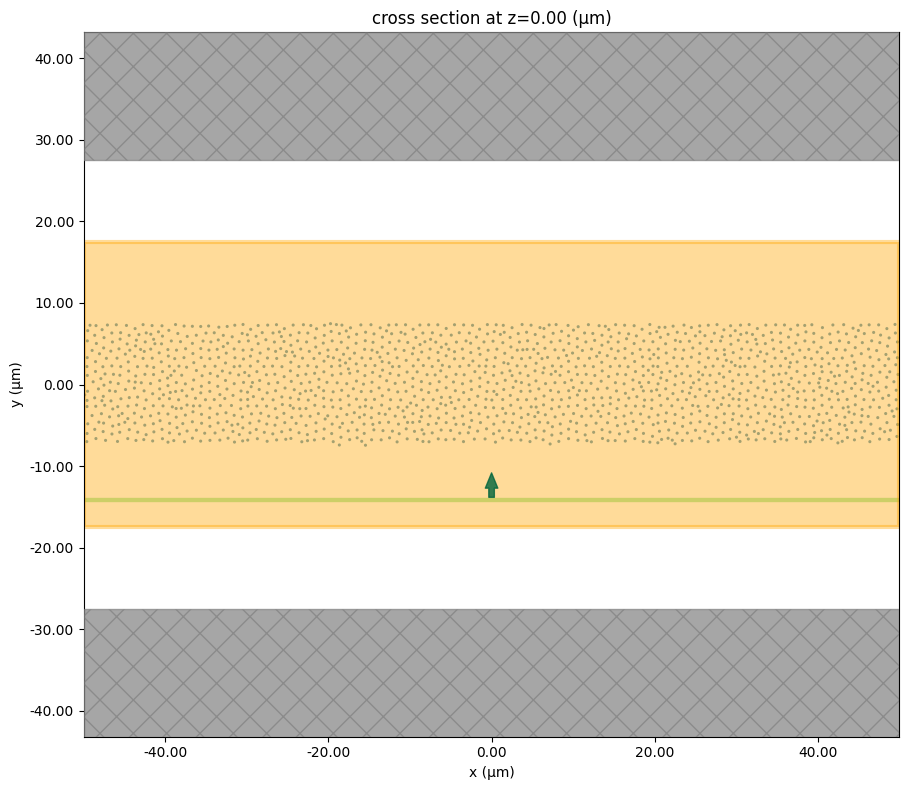

11:45:53 W. Europe Daylight Time Created task 'gyromorph24_2d_K120 Transmission 
                                 6.67 - 1.18_0' with task_id                    
                                 'fdve-ea6df708-eb65-4113-9382-44462582bfc9' and
                                 task_type 'FDTD'.

                                 View task using web UI at                      
                                 ]8;id=366665;https://tidy3d.simulation.cloud/workbench?taskId=fdve-ea6df708-eb65-4113-9382-44462582bfc9\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=928699;https://tidy3d.simulation.cloud/workbench?taskId=fdve-ea6df708-eb65-4113-9382-44462582bfc9\task]8;;\
                                 ]8;id=928699;https://tidy3d.simulation.cloud/workbench?taskId=fdve-ea6df708-eb65-4113-9382-44462582bfc9\Id]8;;\]8;id=366665;https://tidy3d.simulation.cloud/workbench?taskId=fdve-ea6df708-eb65-4113-9382-44462582bfc9\=]8;;\]8;id=326615;https://tidy3d.simulation.cloud/workbench?taskId=fdve-ea6df708-eb65-4113-9382-44462582bfc9\fdve]8;;\]8;id=366665;https://tidy3d.simulation.cloud/workbench?taskId=fdve-ea6df708-eb65-4113-9382-44462582bfc9\-ea6df708-eb65-4113-9382-44462582bfc9']8;;\.

                                 Task folder: ]8;id=305060;https://tidy3d.simulation.cloud/folders/folder-22a7be85-7282-4f7b-9e5c-29522abd0587\'20260526 Transmission gyromorphs ]8;;\
                                 ]8;id=305060;https://tidy3d.simulation.cloud/folders/folder-22a7be85-7282-4f7b-9e5c-29522abd0587\- SHU 100 x 15 Aaron TM Field']8;;\.

Output()

11:45:55 W. Europe Daylight Time Maximum FlexCredit cost: 1.223. Minimum cost   
                                 depends on task execution details. Use         
                                 'web.real_cost(task_id)' to get the billed     
                                 FlexCredit cost after a simulation run.

...

Output()

12:27:09 W. Europe Daylight Time status = postprocess

12:28:36 W. Europe Daylight Time status = success

12:28:38 W. Europe Daylight Time View simulation result at                      
                                 ]8;id=271887;https://tidy3d.simulation.cloud/workbench?taskId=fdve-ce02e407-b4b4-42e3-9c58-646ace3d9680\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=641812;https://tidy3d.simulation.cloud/workbench?taskId=fdve-ce02e407-b4b4-42e3-9c58-646ace3d9680\task]8;;\
                                 ]8;id=641812;https://tidy3d.simulation.cloud/workbench?taskId=fdve-ce02e407-b4b4-42e3-9c58-646ace3d9680\Id]8;;\]8;id=271887;https://tidy3d.simulation.cloud/workbench?taskId=fdve-ce02e407-b4b4-42e3-9c58-646ace3d9680\=]8;;\]8;id=120010;https://tidy3d.simulation.cloud/workbench?taskId=fdve-ce02e407-b4b4-42e3-9c58-646ace3d9680\fdve]8;;\]8;id=271887;https://tidy3d.simulation.cloud/workbench?taskId=fdve-ce02e407-b4b4-42e3-9c58-646ace3d9680\-ce02e407-b4b4-42e3-9c58-646ace3d9680']8;;\.

Folder '../../../data/20260526 Transmission gyromorphs - SHU 100 x 15 Aaron TM Field/gyromorph24_2d_K120' created successfully.
SHU2D_N15700_K100.0 Transmission 6.67 - 1.18
Configured successfully.


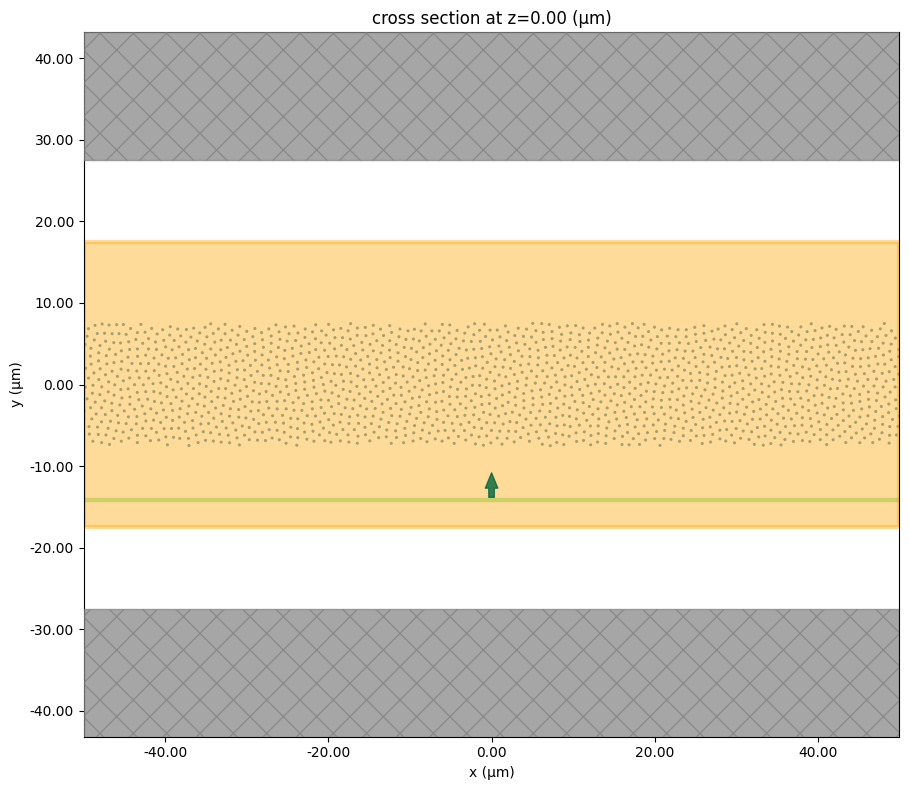

12:28:40 W. Europe Daylight Time Created task 'SHU2D_N15700_K100.0 Transmission 
                                 6.67 - 1.18' with task_id                      
                                 'fdve-dfd23350-d77f-43ed-927b-da2d9dbad7e0' and
                                 task_type 'FDTD'.

                                 View task using web UI at                      
                                 ]8;id=812002;https://tidy3d.simulation.cloud/workbench?taskId=fdve-dfd23350-d77f-43ed-927b-da2d9dbad7e0\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=472958;https://tidy3d.simulation.cloud/workbench?taskId=fdve-dfd23350-d77f-43ed-927b-da2d9dbad7e0\task]8;;\
                                 ]8;id=472958;https://tidy3d.simulation.cloud/workbench?taskId=fdve-dfd23350-d77f-43ed-927b-da2d9dbad7e0\Id]8;;\]8;id=812002;https://tidy3d.simulation.cloud/workbench?taskId=fdve-dfd23350-d77f-43ed-927b-da2d9dbad7e0\=]8;;\]8;id=33208;https://tidy3d.simulation.cloud/workbench?taskId=fdve-dfd23350-d77f-43ed-927b-da2d9dbad7e0\fdve]8;;\]8;id=812002;https://tidy3d.simulation.cloud/workbench?taskId=fdve-dfd23350-d77f-43ed-927b-da2d9dbad7e0\-dfd23350-d77f-43ed-927b-da2d9dbad7e0']8;;\.

                                 Task folder: ]8;id=851047;https://tidy3d.simulation.cloud/folders/folder-22a7be85-7282-4f7b-9e5c-29522abd0587\'20260526 Transmission gyromorphs ]8;;\
                                 ]8;id=851047;https://tidy3d.simulation.cloud/folders/folder-22a7be85-7282-4f7b-9e5c-29522abd0587\- SHU 100 x 15 Aaron TM Field']8;;\.

Output()

12:28:43 W. Europe Daylight Time Maximum FlexCredit cost: 1.223. Minimum cost   
                                 depends on task execution details. Use         
                                 'web.real_cost(task_id)' to get the billed     
                                 FlexCredit cost after a simulation run.

...

Output()

12:48:41 W. Europe Daylight Time status = postprocess

12:52:07 W. Europe Daylight Time status = success

12:52:09 W. Europe Daylight Time View simulation result at                      
                                 ]8;id=470493;https://tidy3d.simulation.cloud/workbench?taskId=fdve-dfd23350-d77f-43ed-927b-da2d9dbad7e0\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=19795;https://tidy3d.simulation.cloud/workbench?taskId=fdve-dfd23350-d77f-43ed-927b-da2d9dbad7e0\task]8;;\
                                 ]8;id=19795;https://tidy3d.simulation.cloud/workbench?taskId=fdve-dfd23350-d77f-43ed-927b-da2d9dbad7e0\Id]8;;\]8;id=470493;https://tidy3d.simulation.cloud/workbench?taskId=fdve-dfd23350-d77f-43ed-927b-da2d9dbad7e0\=]8;;\]8;id=583394;https://tidy3d.simulation.cloud/workbench?taskId=fdve-dfd23350-d77f-43ed-927b-da2d9dbad7e0\fdve]8;;\]8;id=470493;https://tidy3d.simulation.cloud/workbench?taskId=fdve-dfd23350-d77f-43ed-927b-da2d9dbad7e0\-dfd23350-d77f-43ed-927b-da2d9dbad7e0']8;;\.

Folder '../../../data/20260526 Transmission gyromorphs - SHU 100 x 15 Aaron TM Field/SHU2D_N15700_K100.0' created successfully.


In [8]:

for k,item in enumerate(data):
        run_name = f"{Path(os.listdir(folder_path)[k]).stem} Transmission {lambdas[0]:.3g} - {lambdas[1]:.3g}"
        print(run_name)
        
        structure_1 = AM.loadAndRunStructure(key = tidy3dAPI
                    ,direction="z", lambda_range=lambdas,
                    box_size= 50,runtime_ps=runtime_ps,min_steps_per_lambda=min_steps_per_lambda,
                   scaling=1,shuoff_condtion=1e-20, verbose=True,
                   monitors=["flux"],
                   freqs=250, 
                   source="planewave", 
                   width=0.35, ref_only=True
                   )


        sim = structure_1.sim

        boundaries= td.BoundarySpec(
                y=td.Boundary(plus=td.Absorber(num_layers=200),minus=td.Absorber(num_layers=200)),
                x=td.Boundary.periodic(),
                z=td.Boundary.periodic(),
            )
        sim = sim.copy(update={'boundary_spec':boundaries})
        sim = sim.copy(update={'sources':[]})
        sim = sim.copy(update={'monitors':[]})


        sim = sim.copy(update={'size':[Lx,Ly+40,0]})

        source = td.PlaneWave(
                source_time = td.GaussianPulse(
                    freq0=structure_1.freq0,
                    fwidth=structure_1.freqw
                ),
                size= (td.inf,0,td.inf),
                center=(0,-(Ly)/2 - lambdas[0],0),
                direction='+',
                pol_angle=np.pi/2 if polarization == "TM" else 0,
                name='planewave',
                )

        sim = sim.copy(update={'sources':[source]})

      
        monitor_1 = td.FluxMonitor(
                center = (
                                0,-((Ly)/2+3),0
                                ),
                size = (
                   td.inf,0,td.inf
                    ),
                freqs = structure_1.monitor_freqs,
                name='flux2' )

        monitor_2 = td.FluxMonitor(
                center = (
                                0,(Ly)/2+3,0
                                ),
                size = (
                   td.inf,0,td.inf
                    ),
                freqs = structure_1.monitor_freqs,
                name='flux1' 
            )
        
        field_monitor = td.FieldMonitor(
                center = (0,0,0),
                size = (
                   Lx,Ly+20,0
                    ),
                freqs = structure_1.monitor_freqs,
                fields=["Ex", "Ey", "Ez"],
                name='field_monitor' 
            )
        
        monitors =[monitor_1,monitor_2]
        if add_field_monitor:
            monitors=[field_monitor]

        sim = sim.copy(update={'monitors':monitors})

        cyl_group = []
        for x, y in zip(data[k]['x'], data[k]['y']):
            x,y = x*scales_data[k],y*scales_data[k]
            if np.abs(y)<=(Ly/2) and np.abs(x)<=(Lx/2):
                cyl_group.append(td.Cylinder(center=[x, y, 0], radius=0.189, length=td.inf))

        cylinders = td.Structure(geometry=td.GeometryGroup(geometries=cyl_group), medium=medium)


        if empty:
            sim = sim.copy(update={'structures':[],"grid_spec": td.GridSpec.uniform(dl=structure_1.dl)})
        else:
            sim = sim.copy(update={'structures':[cylinders],"grid_spec": td.GridSpec.uniform(dl=structure_1.dl)})

        sim_name = run_name
        fig, ax = plt.subplots(1, tight_layout=True, figsize=(16, 8))
        sim.plot(z=0, ax=ax)
        plt.show()

        if run:
            if add_ref:
                 id0 =web.upload(sim.copy(update={'structures':[]}), folder_name=project_name,task_name=fr"{sim_name}_0", verbose=True)
                 web.start(task_id = id0)
                 web.monitor(task_id=id0,verbose=True)
                 add_ref = False

            id =web.upload(sim, folder_name=project_name,task_name=sim_name, verbose=True)
            web.start(task_id = id)
            web.monitor(task_id=id,verbose=True)
            ids = id0+ '\n' + id
            structure_folder =Path(os.listdir(folder_path)[k]).stem
            file_path = rf"../../../data/{project_name}/{structure_folder}/{sim_name}.txt"
            # Check if the folder exists
            if not os.path.exists( fr"../../../data/{project_name}/{structure_folder}"):
                os.makedirs(fr"../../../data/{project_name}/{structure_folder}",exist_ok=True)
                print(fr"Folder '../../../data/{project_name}/{structure_folder}' created successfully.")

            # Open file in write mode
            with open(file_path, "w") as f:
                # Write the string to the file
                f.write(ids)
        else:
            sim.plot_3d()
            # id =web.upload(sim,task_name=sim_name, verbose=True)
            # print(web.estimate_cost(id))
            raise TypeError("Program ends here")

